In [33]:
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
plt.rcParams['text.usetex']=True

In [34]:
Bdfile = '/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelims_incltauveto_evtdisp/Bd.root'
bbfile = '/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelims_incltauveto_evtdisp/bb.root'
udfile = '/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelims_incltauveto_evtdisp/ud.root'

In [35]:
expressions = [
    "MCem_p",
    "MCem_px",
    "MCem_py",
    "MCem_pz",
    "MCem_orivtx_x",
    "MCem_orivtx_y",
    "MCem_orivtx_z",
    
    "MCep_p",
    "MCep_px",
    "MCep_py",
    "MCep_pz",
    "MCep_orivtx_x",
    "MCep_orivtx_y",
    "MCep_orivtx_z",

    "MCZ_p",
    "MCZ_px",
    "MCZ_py",
    "MCZ_pz",
    "MCZ_orivtx_x",
    "MCZ_orivtx_y",
    "MCZ_orivtx_z",

    "MC_PDG",
    "MC_p",
    "MC_px",
    "MC_py",
    "MC_pz",
    "MC_orivtx_x",
    "MC_orivtx_y",
    "MC_orivtx_z",  
    
    "MC_M1",
    "MC_M2",
    "MC_genStatus",
    "MC_D1",
    
]

expressions += [
    "EVT_Thrust_x",
    "EVT_Thrust_y",
    "EVT_Thrust_z",
]

expressions += [
    "Rec_true_PDG",
    "Rec_true_M1",
    "Rec_true_M2",
    "Rec_true_M1ofM1",
    "Rec_true_M2ofM1",
    "Rec_true_p",
    "Rec_true_px",
    "Rec_true_py",
    "Rec_true_pz",
    "Rec_true_orivtx_x",
    "Rec_true_orivtx_y",
    "Rec_true_orivtx_z",
]

In [36]:
presel_data = uproot.concatenate(Bdfile+':events', expressions=expressions)[53]#5

In [37]:
# Beam electron and positron
emX  = presel_data['MCem_orivtx_x']
emY  = presel_data['MCem_orivtx_y']
emZ  = presel_data['MCem_orivtx_z']
emPX = presel_data['MCem_px']
emPY = presel_data['MCem_py']
emPZ = presel_data['MCem_pz']

epX  = presel_data['MCep_orivtx_x']
epY  = presel_data['MCep_orivtx_y']
epZ  = presel_data['MCep_orivtx_z']
epPX = presel_data['MCep_px']
epPY = presel_data['MCep_py']
epPZ = presel_data['MCep_pz']

# Z boson
zX = presel_data['MCZ_orivtx_x']
zY = presel_data['MCZ_orivtx_y']
zZ = presel_data['MCZ_orivtx_z']

#thrust components
thrustX = presel_data['EVT_Thrust_x']
thrustY = presel_data['EVT_Thrust_y']
thrustZ = presel_data['EVT_Thrust_z']

In [38]:
# Final state particles have initial position from orivtx and final from momentum
feX  = presel_data['Rec_true_orivtx_x'][abs(presel_data['Rec_true_PDG']) == 11].to_numpy()
feY  = presel_data['Rec_true_orivtx_y'][abs(presel_data['Rec_true_PDG']) == 11].to_numpy()
feZ  = presel_data['Rec_true_orivtx_z'][abs(presel_data['Rec_true_PDG']) == 11].to_numpy()
fePX = presel_data['Rec_true_px'][abs(presel_data['Rec_true_PDG']) == 11].to_numpy()
fePY = presel_data['Rec_true_py'][abs(presel_data['Rec_true_PDG']) == 11].to_numpy()
fePZ = presel_data['Rec_true_pz'][abs(presel_data['Rec_true_PDG']) == 11].to_numpy()
feP  = presel_data['Rec_true_p'][abs(presel_data['Rec_true_PDG'])  == 11].to_numpy()

fmuX  = presel_data['Rec_true_orivtx_x'][abs(presel_data['Rec_true_PDG']) == 13].to_numpy()
fmuY  = presel_data['Rec_true_orivtx_y'][abs(presel_data['Rec_true_PDG']) == 13].to_numpy()
fmuZ  = presel_data['Rec_true_orivtx_z'][abs(presel_data['Rec_true_PDG']) == 13].to_numpy()
fmuPX = presel_data['Rec_true_px'][abs(presel_data['Rec_true_PDG']) == 13].to_numpy()
fmuPY = presel_data['Rec_true_py'][abs(presel_data['Rec_true_PDG']) == 13].to_numpy()
fmuPZ = presel_data['Rec_true_pz'][abs(presel_data['Rec_true_PDG']) == 13].to_numpy()
fmuP  = presel_data['Rec_true_p'][abs(presel_data['Rec_true_PDG'])  == 13].to_numpy()

fgamX  = presel_data['Rec_true_orivtx_x'][(abs(presel_data['Rec_true_PDG']) == 22) & (abs(presel_data['Rec_true_M1']) != 11)].to_numpy()
fgamY  = presel_data['Rec_true_orivtx_y'][(abs(presel_data['Rec_true_PDG']) == 22) & (abs(presel_data['Rec_true_M1']) != 11)].to_numpy()
fgamZ  = presel_data['Rec_true_orivtx_z'][(abs(presel_data['Rec_true_PDG']) == 22) & (abs(presel_data['Rec_true_M1']) != 11)].to_numpy()
fgamPX = presel_data['Rec_true_px'][(abs(presel_data['Rec_true_PDG']) == 22) & (abs(presel_data['Rec_true_M1']) != 11)].to_numpy()
fgamPY = presel_data['Rec_true_py'][(abs(presel_data['Rec_true_PDG']) == 22) & (abs(presel_data['Rec_true_M1']) != 11)].to_numpy()
fgamPZ = presel_data['Rec_true_pz'][(abs(presel_data['Rec_true_PDG']) == 22) & (abs(presel_data['Rec_true_M1']) != 11)].to_numpy()
fgamP  = presel_data['Rec_true_p'][(abs(presel_data['Rec_true_PDG'])  == 22) & (abs(presel_data['Rec_true_M1']) != 11)].to_numpy()

fhadX  = presel_data['Rec_true_orivtx_x'][(abs(presel_data['Rec_true_PDG']) == 2212) | (abs(presel_data['Rec_true_PDG']) == 211) | (abs(presel_data['Rec_true_PDG']) == 321)].to_numpy() #ie. requiring k,p,pi (only other non-lepton reco states are n, KL)
fhadY  = presel_data['Rec_true_orivtx_y'][(abs(presel_data['Rec_true_PDG']) == 2212) | (abs(presel_data['Rec_true_PDG']) == 211) | (abs(presel_data['Rec_true_PDG']) == 321)].to_numpy()
fhadZ  = presel_data['Rec_true_orivtx_z'][(abs(presel_data['Rec_true_PDG']) == 2212) | (abs(presel_data['Rec_true_PDG']) == 211) | (abs(presel_data['Rec_true_PDG']) == 321)].to_numpy()
fhadPX = presel_data['Rec_true_px'][(abs(presel_data['Rec_true_PDG']) == 2212) | (abs(presel_data['Rec_true_PDG']) == 211) | (abs(presel_data['Rec_true_PDG']) == 321)].to_numpy()
fhadPY = presel_data['Rec_true_py'][(abs(presel_data['Rec_true_PDG']) == 2212) | (abs(presel_data['Rec_true_PDG']) == 211) | (abs(presel_data['Rec_true_PDG']) == 321)].to_numpy()
fhadPZ = presel_data['Rec_true_pz'][(abs(presel_data['Rec_true_PDG']) == 2212) | (abs(presel_data['Rec_true_PDG']) == 211) | (abs(presel_data['Rec_true_PDG']) == 321)].to_numpy()
fhadP  = presel_data['Rec_true_p'][(abs(presel_data['Rec_true_PDG']) == 2212) | (abs(presel_data['Rec_true_PDG']) == 211) | (abs(presel_data['Rec_true_PDG']) == 321)].to_numpy()


In [39]:

bX = presel_data['MC_orivtx_x'][abs(presel_data['MC_PDG']) == 511].to_numpy()
bY = presel_data['MC_orivtx_y'][abs(presel_data['MC_PDG']) == 511].to_numpy()
bZ = presel_data['MC_orivtx_z'][abs(presel_data['MC_PDG']) == 511].to_numpy()

nuX = presel_data['MC_orivtx_x'][(abs(presel_data['MC_PDG']) == 12)].to_numpy()
nuY = presel_data['MC_orivtx_y'][(abs(presel_data['MC_PDG']) == 12)].to_numpy()
nuZ = presel_data['MC_orivtx_z'][(abs(presel_data['MC_PDG']) == 12)].to_numpy()

nuP = presel_data["MC_p"][(abs(presel_data['MC_PDG']) == 12)].to_numpy()
nuPX = presel_data["MC_px"][(abs(presel_data['MC_PDG']) == 12)].to_numpy()
nuPY = presel_data["MC_py"][(abs(presel_data['MC_PDG']) == 12)].to_numpy()
nuPZ = presel_data["MC_pz"][(abs(presel_data['MC_PDG']) == 12)].to_numpy()




In [40]:
presel_data['MC_M1'][(abs(presel_data['MC_PDG']) == 12)].to_numpy()

array([47, 47], dtype=int32)

In [41]:
print(bX,bY,bZ,nuX,nuY,nuZ)

[0.00044221 0.00044221] [-6.45635e-05 -6.45635e-05] [0.53898305 0.53898305] [0.44238728 0.44238728] [1.8298408 1.8298408] [-3.258841 -3.258841]


In [42]:
SVX  = presel_data['Rec_true_orivtx_x'][(presel_data['Rec_true_orivtx_x']!= zX)&(abs(presel_data['Rec_true_PDG']) != 22)].to_numpy()
SVY  = presel_data['Rec_true_orivtx_y'][(presel_data['Rec_true_orivtx_y']!= zY) &(abs(presel_data['Rec_true_PDG']) != 22)].to_numpy()
SVZ  = presel_data['Rec_true_orivtx_z'][(presel_data['Rec_true_orivtx_z']!= zZ) &(abs(presel_data['Rec_true_PDG']) != 22)].to_numpy()

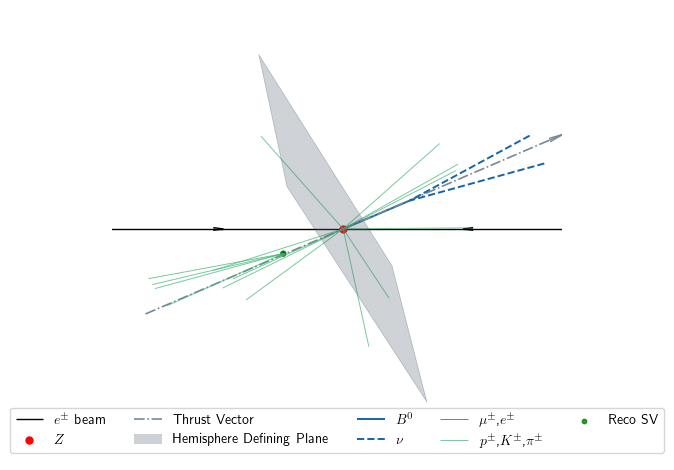

In [43]:
#nb. all points translated by PV position so that it becomes the origin of the plot

quiver_opts = {
    'arrow_length_ratio': 0,
    'length': 8,
    'antialiased': True,
}

incident_e_arrows_opts = {
    'arrow_length_ratio': 1,
    'length': 0.6,
    'antialiased': True,
}

incident_e_line_opts = {
    'arrow_length_ratio': 0,
    'length': 25,
    'antialiased': True,
}

thrust_opts = {
    'arrow_length_ratio': 0,
    'length': 9,
    'antialiased': True,
}


fig = plt.figure(facecolor='white')
ax = fig.add_subplot(111, projection='3d')#, facecolor='white')
ax.grid(visible=False)

#add electron beam
#add electron beam
ax.quiver([0.3*incident_e_line_opts['length'], -0.3*incident_e_line_opts['length']], [-0, -0], [-0, -0], [-emPZ, -epPZ], [-emPY, -epPY], [-emPX, -epPX],
          color='black',
          normalize=True, linewidth=1,zorder=1, **incident_e_arrows_opts)
ax.quiver([emZ-zZ, epZ-zZ], [emY-zY, epY-zY], [emX-zX, epX-zX], [-emPZ, -epPZ], [-emPY, -epPY], [-emPX, -epPX], 
          color='black',  label=r'$e^\pm$ beam', 
          normalize=True, linewidth=1,zorder=0, **incident_e_line_opts)
       

#add Z boson
ax.scatter3D(0, 0, 0, color='red', label=r'$Z$', s=25, zorder=12)


#add thrust
ax.quiver(0, 0, 0, thrustZ, thrustY, thrustX, color='lightslategray', label=r'Thrust Vector', **thrust_opts, linestyle='dashdot', linewidth=1.2,zorder=2)#'hotpink'
ax.quiver(0, 0, 0, -thrustZ, -thrustY, -thrustX, color='lightslategray',  **thrust_opts, linestyle='dashdot', linewidth=1.2,zorder=3)#'hotpink'
# Plot solid arrowhead 
ax.quiver(thrustZ*thrust_opts['length'], thrustY*thrust_opts['length'], thrustX*thrust_opts['length'],thrustZ,thrustY,thrustX,color='lightslategray',arrow_length_ratio=1,linewidth=1, length=0.6)# 'hotpink'

#add plane separating hemispheres
normal = np.array([thrustX, thrustY, thrustZ])  
# PV which is in the plane
PV = np.array([0, 0, 0])  # Replace with your actual point
# Create grid in x-y 
d = PV.dot(normal)  # Plane equation: ax + by + cz = d
# Create a meshgrid
xx, yy = np.meshgrid(np.linspace( - 8,  8, 30),
                     np.linspace( - 8,  8, 30))
# Solve for z from the plane equation: z = (-a*x - b*y + d)/c
if normal[2] != 0:
    zz = (-normal[0] * xx - normal[1] * yy + d) / normal[2]
    
    # Plot the plane
    ax.plot_surface(zz, yy, xx, alpha=0.3, color='lightslategray', label='Hemisphere Defining Plane',zorder=4) #'hotpink'

    x_corners = [xx[0,0], xx[0,-1], xx[-1,-1], xx[-1,0], xx[0,0]]
    y_corners = [yy[0,0], yy[0,-1], yy[-1,-1], yy[-1,0], yy[0,0]]
    z_corners = [zz[0,0], zz[0,-1], zz[-1,-1], zz[-1,0], zz[0,0]]
    ax.plot(z_corners, y_corners, x_corners, color='lightslategray', linewidth=0.5,zorder=5,alpha=0.5) #'hotpink'

#Add Bs2nunu
ax.quiver(bZ[0]-zZ,bY[0]-zY,bX[0]-zX,nuZ[0]-bZ[0],nuY[0]-bY[0],nuX[0]-bX[0], color=plt.cm.Blues( np.linspace(0, 1, 6)[4]) , label=r'$B^0$', arrow_length_ratio=0, linewidth=1.4)
ax.quiver(nuZ-zZ, nuY-zY, nuX-zY, nuPZ/nuP, nuPY/nuP, nuPX/nuP, color=plt.cm.Blues( np.linspace(0, 1, 6)[4]), label=r'$\nu$', **quiver_opts, linestyle='--', linewidth=1.4)

#add reco particles
ax.quiver(fmuZ-zZ, fmuY-zY, fmuX-zX, fmuPZ/fmuP, fmuPY/fmuP, fmuPX/fmuP,label=r'$\mu^\pm$,$e^\pm$', linewidth=0.7, color='darkviolet',**quiver_opts,alpha=0.7)
ax.quiver(feZ-zZ, feY-zY, feX-zX, fePZ/feP, fePY/feP, fePX/feP, color='darkviolet', **quiver_opts, linewidth=0.7,alpha=0.7)
ax.quiver(fhadZ-zZ, fhadY-zY, fhadX-zX, fhadPZ/fhadP, fhadPY/fhadP, fhadPX/fhadP, color='mediumseagreen', label='$p^\pm$,$K^\pm$,$\pi^\pm$', **quiver_opts, linewidth=0.7, alpha=0.7)
#ax.quiver(fgamZ-zZ, fgamY-zY, fgamX-zX, fgamPZ/fgamP, fgamPY/fgamP, fgamPX/fgamP, color='goldenrod', label=r'$\gamma$', **quiver_opts, linewidth=0.7, linestyle=':')

#secondary vertices
ax.scatter3D(SVZ-zZ, SVY-zY, SVX-zX, color='green', label=r'Reco SV', s=10, zorder=13, alpha = 0.8) #(excluding photon producing vertices)'

#set view
ax.view_init(elev=-50., azim=90)

ax.set_xlim([-8, 8])
ax.set_ylim([-8, 8])
ax.set_zlim([-8, 8])
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_axis_off()
ax.legend(loc='lower center', ncols=5, fontsize=10, labelcolor='black', facecolor='white')
fig.tight_layout()

''' Cav add grid to orient yourself
# Define grid range
x = np.linspace(-8, 8, 8)
y = np.linspace(-8, 8, 8)
z = np.linspace(-8, 8, 8)

# Plot grid lines in x-y plane (z=const)
for zc in z:
    for xi in x:
        ax.plot([xi]*len(y), y, [zc]*len(y), color='lightgray', linewidth=0.5)
    for yi in y:
        ax.plot(x, [yi]*len(x), [zc]*len(x), color='lightgray', linewidth=0.5)

# Plot grid lines in x-z plane (y=const)
for yc in y:
    for xi in x:
        ax.plot([xi]*len(z), [yc]*len(z), z, color='lightgray', linewidth=0.5)
    for zi in z:
        ax.plot(x, [yc]*len(x), [zi]*len(x), color='lightgray', linewidth=0.5)

# Plot grid lines in y-z plane (x=const)
for xc in x:
    for yi in y:
        ax.plot([xc]*len(z), y, z, color='lightgray', linewidth=0.5)
    for zi in z:
        ax.plot([xc]*len(y), y, [zi]*len(y), color='lightgray', linewidth=0.5)
'''


plt.savefig('demo1.pdf', bbox_inches='tight')
plt.show()

### nb. event displays currently only show MC $e^\pm$ beam, $B^0$, $\nu\bar{\nu}$

All other particles are true reco particles ie. reconstructed (final state) particles 

ie. $K^\pm$, $\pi^\pm$, $K_L^0$, $e^\pm$, $\mu^\pm$, $\gamma$, $p^\pm$ (therefore dont show intermediate particles that decay at SV)


In [44]:
presel_data_bb = uproot.concatenate(bbfile+':events', expressions=expressions)[19]#5

In [45]:
# Beam electron and positron
emX  = presel_data_bb['MCem_orivtx_x']
emY  = presel_data_bb['MCem_orivtx_y']
emZ  = presel_data_bb['MCem_orivtx_z']
emPX = presel_data_bb['MCem_px']
emPY = presel_data_bb['MCem_py']
emPZ = presel_data_bb['MCem_pz']

epX  = presel_data_bb['MCep_orivtx_x']
epY  = presel_data_bb['MCep_orivtx_y']
epZ  = presel_data_bb['MCep_orivtx_z']
epPX = presel_data_bb['MCep_px']
epPY = presel_data_bb['MCep_py']
epPZ = presel_data_bb['MCep_pz']

# Z boson
zX = presel_data_bb['MCZ_orivtx_x']
zY = presel_data_bb['MCZ_orivtx_y']
zZ = presel_data_bb['MCZ_orivtx_z']

#thrust components
thrustX = presel_data_bb['EVT_Thrust_x']
thrustY = presel_data_bb['EVT_Thrust_y']
thrustZ = presel_data_bb['EVT_Thrust_z']

# Final state particles have initial position from orivtx and final from momentum
feX  = presel_data_bb['Rec_true_orivtx_x'][abs(presel_data_bb['Rec_true_PDG']) == 11].to_numpy()
feY  = presel_data_bb['Rec_true_orivtx_y'][abs(presel_data_bb['Rec_true_PDG']) == 11].to_numpy()
feZ  = presel_data_bb['Rec_true_orivtx_z'][abs(presel_data_bb['Rec_true_PDG']) == 11].to_numpy()
fePX = presel_data_bb['Rec_true_px'][abs(presel_data_bb['Rec_true_PDG']) == 11].to_numpy()
fePY = presel_data_bb['Rec_true_py'][abs(presel_data_bb['Rec_true_PDG']) == 11].to_numpy()
fePZ = presel_data_bb['Rec_true_pz'][abs(presel_data_bb['Rec_true_PDG']) == 11].to_numpy()
feP  = presel_data_bb['Rec_true_p'][abs(presel_data_bb['Rec_true_PDG'])  == 11].to_numpy()

fmuX  = presel_data_bb['Rec_true_orivtx_x'][abs(presel_data_bb['Rec_true_PDG']) == 13].to_numpy()
fmuY  = presel_data_bb['Rec_true_orivtx_y'][abs(presel_data_bb['Rec_true_PDG']) == 13].to_numpy()
fmuZ  = presel_data_bb['Rec_true_orivtx_z'][abs(presel_data_bb['Rec_true_PDG']) == 13].to_numpy()
fmuPX = presel_data_bb['Rec_true_px'][abs(presel_data_bb['Rec_true_PDG']) == 13].to_numpy()
fmuPY = presel_data_bb['Rec_true_py'][abs(presel_data_bb['Rec_true_PDG']) == 13].to_numpy()
fmuPZ = presel_data_bb['Rec_true_pz'][abs(presel_data_bb['Rec_true_PDG']) == 13].to_numpy()
fmuP  = presel_data_bb['Rec_true_p'][abs(presel_data_bb['Rec_true_PDG'])  == 13].to_numpy()

fgamX  = presel_data_bb['Rec_true_orivtx_x'][(abs(presel_data_bb['Rec_true_PDG']) == 22) & (abs(presel_data_bb['Rec_true_M1']) != 11)].to_numpy()
fgamY  = presel_data_bb['Rec_true_orivtx_y'][(abs(presel_data_bb['Rec_true_PDG']) == 22) & (abs(presel_data_bb['Rec_true_M1']) != 11)].to_numpy()
fgamZ  = presel_data_bb['Rec_true_orivtx_z'][(abs(presel_data_bb['Rec_true_PDG']) == 22) & (abs(presel_data_bb['Rec_true_M1']) != 11)].to_numpy()
fgamPX = presel_data_bb['Rec_true_px'][(abs(presel_data_bb['Rec_true_PDG']) == 22) & (abs(presel_data_bb['Rec_true_M1']) != 11)].to_numpy()
fgamPY = presel_data_bb['Rec_true_py'][(abs(presel_data_bb['Rec_true_PDG']) == 22) & (abs(presel_data_bb['Rec_true_M1']) != 11)].to_numpy()
fgamPZ = presel_data_bb['Rec_true_pz'][(abs(presel_data_bb['Rec_true_PDG']) == 22) & (abs(presel_data_bb['Rec_true_M1']) != 11)].to_numpy()
fgamP  = presel_data_bb['Rec_true_p'][(abs(presel_data_bb['Rec_true_PDG'])  == 22) & (abs(presel_data_bb['Rec_true_M1']) != 11)].to_numpy()

fhadX  = presel_data_bb['Rec_true_orivtx_x'][(abs(presel_data_bb['Rec_true_PDG']) == 2212) | (abs(presel_data_bb['Rec_true_PDG']) == 211) | (abs(presel_data_bb['Rec_true_PDG']) == 321)].to_numpy() #ie. requiring k,p,pi (only other non-lepton reco states are n, KL)
fhadY  = presel_data_bb['Rec_true_orivtx_y'][(abs(presel_data_bb['Rec_true_PDG']) == 2212) | (abs(presel_data_bb['Rec_true_PDG']) == 211) | (abs(presel_data_bb['Rec_true_PDG']) == 321)].to_numpy()
fhadZ  = presel_data_bb['Rec_true_orivtx_z'][(abs(presel_data_bb['Rec_true_PDG']) == 2212) | (abs(presel_data_bb['Rec_true_PDG']) == 211) | (abs(presel_data_bb['Rec_true_PDG']) == 321)].to_numpy()
fhadPX = presel_data_bb['Rec_true_px'][(abs(presel_data_bb['Rec_true_PDG']) == 2212) | (abs(presel_data_bb['Rec_true_PDG']) == 211) | (abs(presel_data_bb['Rec_true_PDG']) == 321)].to_numpy()
fhadPY = presel_data_bb['Rec_true_py'][(abs(presel_data_bb['Rec_true_PDG']) == 2212) | (abs(presel_data_bb['Rec_true_PDG']) == 211) | (abs(presel_data_bb['Rec_true_PDG']) == 321)].to_numpy()
fhadPZ = presel_data_bb['Rec_true_pz'][(abs(presel_data_bb['Rec_true_PDG']) == 2212) | (abs(presel_data_bb['Rec_true_PDG']) == 211) | (abs(presel_data_bb['Rec_true_PDG']) == 321)].to_numpy()
fhadP  = presel_data_bb['Rec_true_p'][(abs(presel_data_bb['Rec_true_PDG']) == 2212) | (abs(presel_data_bb['Rec_true_PDG']) == 211) | (abs(presel_data_bb['Rec_true_PDG']) == 321)].to_numpy()

SVX  = presel_data_bb['Rec_true_orivtx_x'][(presel_data_bb['Rec_true_orivtx_x']!= zX)&(abs(presel_data_bb['Rec_true_PDG']) != 22)].to_numpy()
SVY  = presel_data_bb['Rec_true_orivtx_y'][(presel_data_bb['Rec_true_orivtx_y']!= zY) &(abs(presel_data_bb['Rec_true_PDG']) != 22)].to_numpy()
SVZ  = presel_data_bb['Rec_true_orivtx_z'][(presel_data_bb['Rec_true_orivtx_z']!= zZ) &(abs(presel_data_bb['Rec_true_PDG']) != 22)].to_numpy()



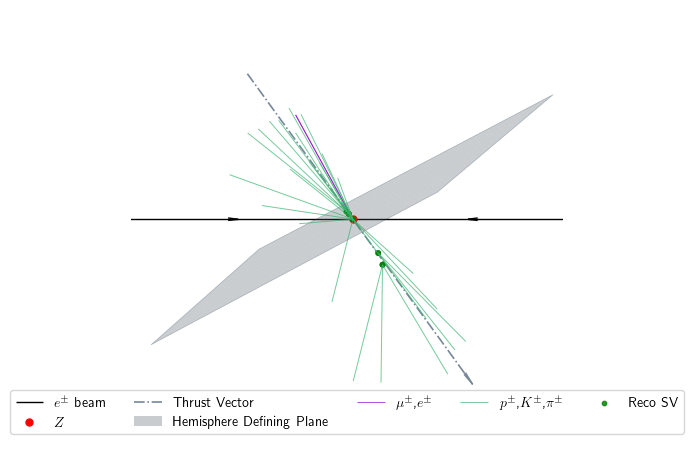

In [46]:
#nb. all points translated by PV position so that it becomes the origin of the plot

quiver_opts = {
    'arrow_length_ratio': 0,
    'length': 8,
    'antialiased': True,
}

incident_e_arrows_opts = {
    'arrow_length_ratio': 1,
    'length': 0.6,
    'antialiased': True,
}

incident_e_line_opts = {
    'arrow_length_ratio': 0,
    'length': 25,
    'antialiased': True,
}

thrust_opts = {
    'arrow_length_ratio': 0,
    'length': 8.5,
    'antialiased': True,
}


fig = plt.figure(facecolor='white')
ax = fig.add_subplot(111, projection='3d')#, facecolor='white')
ax.grid(visible=False)

#add electron beam
ax.quiver([0.3*incident_e_line_opts['length'], -0.3*incident_e_line_opts['length']], [-0, -0], [-0, -0], [-emPZ, -epPZ], [-emPY, -epPY], [-emPX, -epPX],
          color='black',
          normalize=True, linewidth=1, **incident_e_arrows_opts)
ax.quiver([emZ-zZ, epZ-zZ], [emY-zY, epY-zY], [emX-zX, epX-zX], [-emPZ, -epPZ], [-emPY, -epPY], [-emPX, -epPX], 
          color='black',  label=r'$e^\pm$ beam', 
          normalize=True, linewidth=1, **incident_e_line_opts)
       

#add Z boson
ax.scatter3D(0, 0, 0, color='red', label=r'$Z$', s=25)


#add thrust
ax.quiver(0, 0, 0, thrustZ, thrustY, thrustX, color='lightslategray', label=r'Thrust Vector', **thrust_opts, linestyle='dashdot', linewidth=1.2)#'hotpink'
ax.quiver(0, 0, 0, -thrustZ, -thrustY, -thrustX, color='lightslategray',  **thrust_opts, linestyle='dashdot', linewidth=1.2)#'hotpink'

# Plot solid arrowhead 
ax.quiver(thrustZ*thrust_opts['length'], thrustY*thrust_opts['length'], thrustX*thrust_opts['length'],thrustZ,thrustY,thrustX,color='lightslategray',arrow_length_ratio=1,linewidth=1, length=0.6)#'hotpink'


#add plane separating hemispheres
normal = np.array([thrustX, thrustY, thrustZ])  
# PV which is in the plane
PV = np.array([0, 0, 0])  # Replace with your actual point
# Create grid in x-y 
d = PV.dot(normal)  # Plane equation: ax + by + cz = d
# Create a meshgrid
xx, yy = np.meshgrid(np.linspace( - 6,  6, 30),
                     np.linspace( - 6,  6, 30))
# Solve for z from the plane equation: z = (-a*x - b*y + d)/c
if normal[2] != 0:
    zz = (-normal[0] * xx - normal[1] * yy + d) / normal[2]
    
    # Plot the plane
    ax.plot_surface(zz, yy, xx, alpha=0.3, color='lightslategray', label='Hemisphere Defining Plane')#'hotpink'

    x_corners = [xx[0,0], xx[0,-1], xx[-1,-1], xx[-1,0], xx[0,0]]
    y_corners = [yy[0,0], yy[0,-1], yy[-1,-1], yy[-1,0], yy[0,0]]
    z_corners = [zz[0,0], zz[0,-1], zz[-1,-1], zz[-1,0], zz[0,0]]
    ax.plot(z_corners, y_corners, x_corners, color='lightslategray', linewidth=0.5,alpha=0.5)#'hotpink'
'''
#Add Bs2nunu
ax.quiver(bZ[0]-zZ,bY[0]-zY,bX[0]-zX,nuZ[0]-bZ[0],nuY[0]-bY[0],nuX[0]-bX[0], color=plt.cm.Blues( np.linspace(0, 1, 6)[4]) , label=r'$B^0$', arrow_length_ratio=0, linewidth=1.4)
ax.quiver(nuZ-zZ, nuY-zY, nuX-zY, nuPZ/nuP, nuPY/nuP, nuPX/nuP, color=plt.cm.Blues( np.linspace(0, 1, 6)[4]), label=r'$\nu$', **quiver_opts, linestyle='--', linewidth=1.4)
'''
#add reco particles
ax.quiver(fmuZ-zZ, fmuY-zY, fmuX-zX, fmuPZ/fmuP, fmuPY/fmuP, fmuPX/fmuP, label=r'$\mu^\pm$,$e^\pm$', linewidth=0.7, alpha=0.7, color='darkviolet',**quiver_opts)
ax.quiver(feZ-zZ, feY-zY, feX-zX, fePZ/feP, fePY/feP, fePX/feP, color='darkviolet', **quiver_opts, linewidth=0.7, alpha=0.7)
ax.quiver(fhadZ-zZ, fhadY-zY, fhadX-zX, fhadPZ/fhadP, fhadPY/fhadP, fhadPX/fhadP, color='mediumseagreen', label='$p^\pm$,$K^\pm$,$\pi^\pm$', **quiver_opts, linewidth=0.7, alpha=0.7)

#ax.quiver(fgamZ-zZ, fgamY-zY, fgamX-zX, fgamPZ/fgamP, fgamPY/fgamP, fgamPX/fgamP, color='goldenrod', label=r'$\gamma$', **quiver_opts, linewidth=0.7, linestyle=':')

#secondary vertices
ax.scatter(SVZ-zZ, SVY-zY, SVX-zX, color='green', label=r'Reco SV', s=10, alpha = 0.8) #(excluding photon producing vertices)'

#set view
ax.view_init(elev=50., azim=-90)

ax.set_xlim([-8, 8])
ax.set_ylim([-8, 8])
ax.set_zlim([-8, 8])
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_axis_off()
ax.legend(loc='lower center', ncols=5, fontsize=10, labelcolor='black', facecolor='white')
fig.tight_layout()

''' Cav add grid to orient yourself
# Define grid range
x = np.linspace(-8, 8, 8)
y = np.linspace(-8, 8, 8)
z = np.linspace(-8, 8, 8)

# Plot grid lines in x-y plane (z=const)
for zc in z:
    for xi in x:
        ax.plot([xi]*len(y), y, [zc]*len(y), color='lightgray', linewidth=0.5)
    for yi in y:
        ax.plot(x, [yi]*len(x), [zc]*len(x), color='lightgray', linewidth=0.5)

# Plot grid lines in x-z plane (y=const)
for yc in y:
    for xi in x:
        ax.plot([xi]*len(z), [yc]*len(z), z, color='lightgray', linewidth=0.5)
    for zi in z:
        ax.plot(x, [yc]*len(x), [zi]*len(x), color='lightgray', linewidth=0.5)

# Plot grid lines in y-z plane (x=const)
for xc in x:
    for yi in y:
        ax.plot([xc]*len(z), y, z, color='lightgray', linewidth=0.5)
    for zi in z:
        ax.plot([xc]*len(y), y, [zi]*len(y), color='lightgray', linewidth=0.5)
'''


plt.savefig('demo1bb.pdf', bbox_inches='tight')
plt.show()

In [30]:
#Check final state hadrons
final_PIDs=[]
for i in range(500):
    presel_data_bb_full = uproot.concatenate(bbfile+':events', expressions=expressions)[i]
    final_PIDs.extend(set(presel_data_bb_full['Rec_true_PDG'][(abs(presel_data_bb_full['Rec_true_PDG']) != 11) & (abs(presel_data_bb_full['Rec_true_PDG']) != 13) & (abs(presel_data_bb_full['Rec_true_PDG']) != 22)].to_numpy()))

set(final_PIDs)

{-2212.0, -2112.0, -321.0, -211.0, 130.0, 211.0, 321.0, 2112.0, 2212.0}